# Jeu de traces simulées à partir d'un réseau

Nous présentons ici un exemple simple et complet reposant sur une collection de traces simulées à partir d’un réseau. 

Ce pipeline est exécuté en une seule itération.

Le réseau est un extrait de la BDTOPO situé sur un versant de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons.

## Import des librairies

- Les deux librairies socles : tracklib et OFNP 
* Pour visualiser les résultats : matplotlib

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

## Import des données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



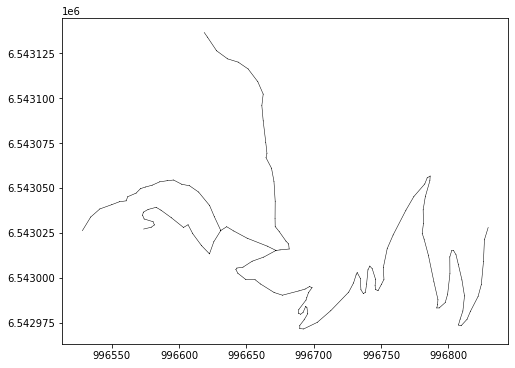

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network2.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (500 of 500) |######################| Elapsed Time: 0:00:09 Time:  0:00:090000


------------------------------------------------------------
444 (88.8 %) tracks generated on network
------------------------------------------------------------


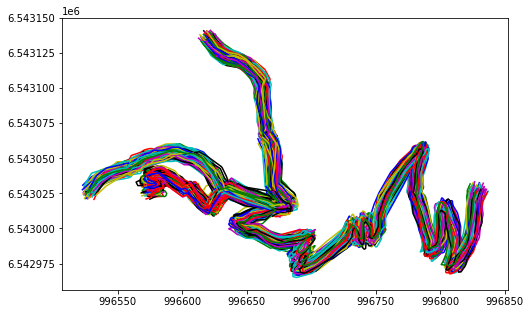

In [3]:
tkl.stochastics.seed(333)
#
noiser = tkl.NoiseProcess(amps=2.5, kernels=tkl.ExponentialKernel(80))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=500, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)
#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

import os
import shutil

# Suppression des répertoires
for filename in os.listdir(RESPATH):
    file_path = os.path.join(RESPATH, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

# Création des répertoires
setupenv(RESPATH)


## Step 1 : segmentation and resampling

In [5]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks after segmentation: 444
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  444
    Number of tracks after resampling: 444
    Number of tracks after resampling: 444
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [6]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30

SEUIL_DENSITE = 180  # pas d'unité 
SEUIL_SURFACE = 1000 # m2

cut_factor = 5

closing = False

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE, closing,
                       prefix='PT', rep='resample_grid', cut_factor=cut_factor)



Starting rasterization and vectorization
    Number of tracks to load:  444
Starting heatmap computation ...
    Execution time (seconds): 2.7220332622528076
    Finished heatmap computation.
Starting morphological opening ...
    Execution time (seconds): 0.009377479553222656
    Finished morphological opening.
Vectorizing ...
    Number of polygonize features:  2
    Number of polygonize features copied:  1
    Execution time (seconds): 0.019199848175048828
    Vectorization completed.
Smoothing polygon to remove stair-step artifacts ...


100% (1411 of 1411) |####################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.07749724388122559
    Road surface smoothing completed.
Starting centerline computation ...
    Execution time (seconds): 0.13732600212097168
    Centerline computed.
Stage 2 completed: rasterization and vectorization.


Text(0.5, 1.0, 'Road surface lissée')

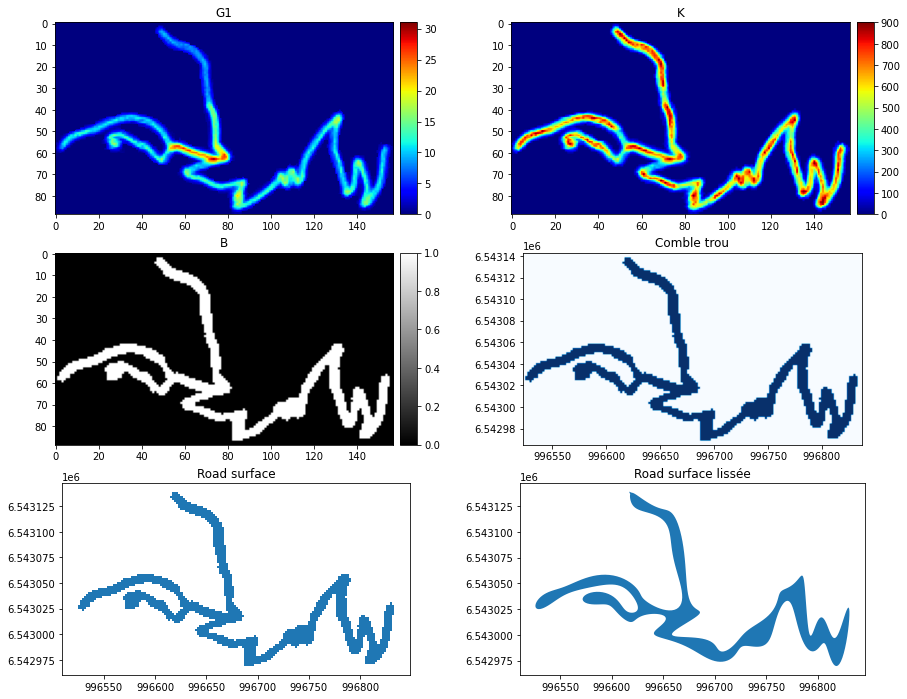

In [7]:
from ofnp import matPlotShapefile, matPlotRasterShp, maPlotRasterTiff

plt.figure(figsize=(15, 12))

# ----------------------------------------------------------------------------------------------------------
ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_PT.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', vmin=0, append=ax1)

# ----------------------------------------------------------------------------------------------------------
ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_PT.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

# ----------------------------------------------------------------------------------------------------------
ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_PT.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

# ----------------------------------------------------------------------------------------------------------
ax4 = plt.subplot2grid((3, 2), (1, 1))
if closing:
    maPlotRasterTiff(RESPATH, 'image/erosion_PT.tif', ax4)
    ax4.set_title('Closing')
else:
    maPlotRasterTiff(RESPATH, 'image/rien_PT.tif', ax4)
    ax4.set_title('Comble trou')

# ----------------------------------------------------------------------------------------------------------
ax5 = plt.subplot2grid((3, 2), (2, 0))
matPlotRasterShp(RESPATH, 'image/road_surface_PT.shp', ax5)
ax5.set_title('Road surface')

# ----------------------------------------------------------------------------------------------------------
ax6 = plt.subplot2grid((3, 2), (2, 1))
matPlotRasterShp(RESPATH, 'image/road_surface_lissee_PT.shp', ax6)
ax6.set_title('Road surface lissée')

## Step 3 : création de la center line

In [8]:
from ofnp import addTopologyToNetwork

SEARCH = 25
h=3
addTopologyToNetwork(RESPATH, SEARCH, h=h)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_PT.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)
print ('-----------------------------------------------------------------')

100% (16 of 16) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


Starting topology creation for the network
    Number of edges in the skeleton: 278
    Finished loaded skeleton.
Finished removing hooked parts of the skeleton.
Finished simplification of the skeleton.
    on coupe la trace 1
    Number of edges in the simplified skeleton: 17
    Number of nodes: 18
    Conflation cannot be performed for node  9 ; the three incident edges are too long: 123 67 32
Nb arcs après la conflation = 5
Stage 3 completed: adding topology to the skeleton.
-----------------------------------------------------------------


Text(0.5, 1.0, 'squelette simplifié avec topologie')

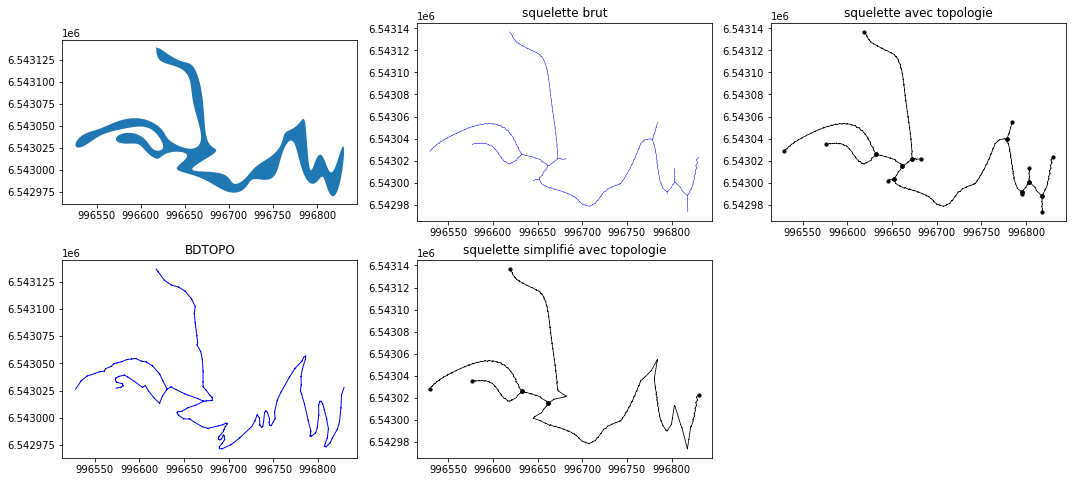

In [9]:
from ofnp import plotSqueletteTopo

plt.figure(figsize=(18, 8))

ax1 = plt.subplot2grid((2, 3), (0, 0))
matPlotRasterShp(RESPATH, 'image/road_surface_lissee_PT.shp', ax1)
ax5.set_title('Road surface')

ax2 = plt.subplot2grid((2, 3), (0, 1))
matPlotShapefile(RESPATH + 'network/', 'squelette_PT.shp', ax2)
ax2.set_title('squelette brut')

ax3 = plt.subplot2grid((2, 3), (0, 2))
plotSqueletteTopo(RESPATH, ax3)
ax3.set_title('squelette avec topologie')

ax4 = plt.subplot2grid((2, 3), (1, 0))
network.plot(edges='b-', size=1.0, append=ax4)
ax4.set_title('BDTOPO')

ax5 = plt.subplot2grid((2, 3), (1, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax5)
ax5.set_title('squelette simplifié avec topologie')

## Step 4 : Construction des géométries agrégées pour chaque arc du squelette

1. Attribue les points des traces brutes à chaque arc de la topologie
	- Recalage avec l’algorithme de Newson and Krumm (2009)
2. Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
3. Agrégation des morceaux de traces
4. Conflation des traces fusionnées afin d’obtenir un réseau de mobilité   

In [10]:
from ofnp import createNetworkGeom

BUFFER = 25
createNetworkGeom(RESPATH, SEARCH, BUFFER)


Starting map-matching, aggregation, and conflation of GNSS trajectories.
Loading network ...
    Number of edges =  5
    Number of nodes =  6
    Total segment length of the network =  782.1574203734526
Loading collection of tracks ...


100% (6 of 6) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00


    Number of tracks: 444
    Execution time (seconds): 0.5643703937530518
Starting map-matching ...
Map-matching preparation...
    Map-matching ended.
    Execution time (seconds): 5.890994310379028
    Map-matching results restructuring completed.
    Map-matching results exported.
Starting construction of candidate trajectory segments for each topology edge ...
    Segment construction completed.
    Execution time (seconds): 2.3929598331451416
Starting aggregation ...
    Aggregation for arc number: 19
        Number of candidate tracks / number of sampled tracks 62 / 30
    Aggregation for arc number: 8
        Number of candidate tracks / number of sampled tracks 290 / 30
    Aggregation for arc number: 22
        Number of candidate tracks / number of sampled tracks 138 / 30
    Aggregation for arc number: 6
        Number of candidate tracks / number of sampled tracks 111 / 30
    Aggregation for arc number: 7
        Number of candidate tracks / number of sampled tracks 123 /

### Visualisation du recalage sur le réseau

Text(0.5, 1.0, 'Résultat du map-matching')

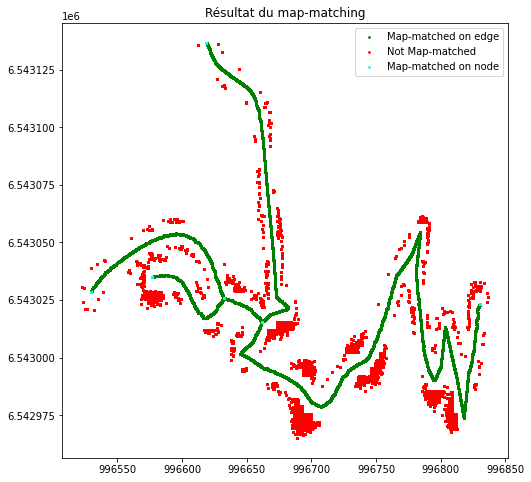

In [11]:
from ofnp import plotMM

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotMM(RESPATH, ax1)
ax1.set_title('Résultat du map-matching')

### Visualisation des candidats pour l'agrégation

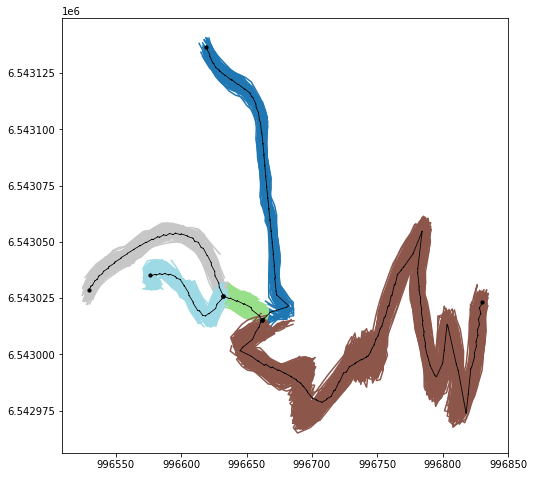

In [12]:
from ofnp import plotSegmentsConstruction

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotSegmentsConstruction(RESPATH, ax1, squelette)

### Visualisation de l'agrégation et de la conflation

Text(0.5, 1.0, 'CONFLATION')

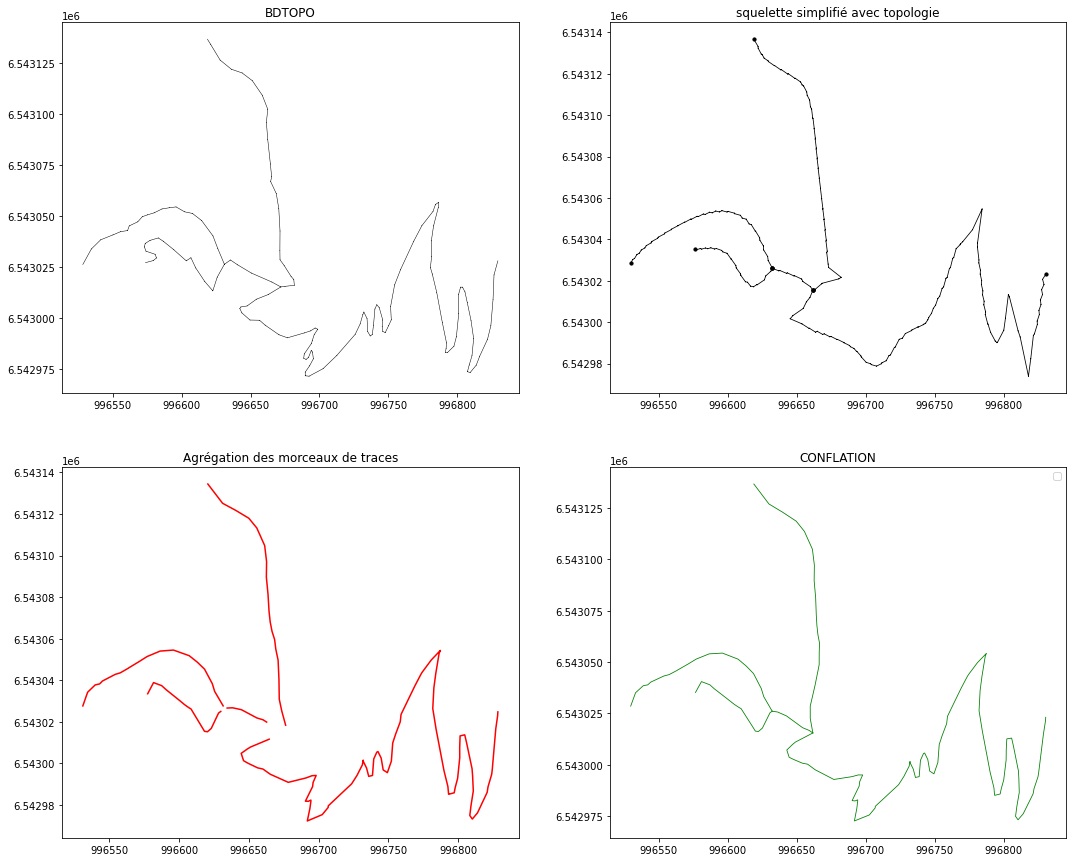

In [13]:
from ofnp import plotAggregation, plotConflation
import os

plt.figure(figsize=(18, 15))

# ---------------------------------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0))
network.plot('k-', '', 'g-', 'r-', 0.5, ax1)
ax1.set_title('BDTOPO')

# ---------------------------------------------------
ax2 = plt.subplot2grid((2, 2), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette simplifié avec topologie')

# ---------------------------------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
plotAggregation(RESPATH, ax3)
ax3.set_title('Agrégation des morceaux de traces')

# ---------------------------------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
plotConflation(RESPATH, ax4)
ax4.set_title('CONFLATION')


## Visualisation du résultat final

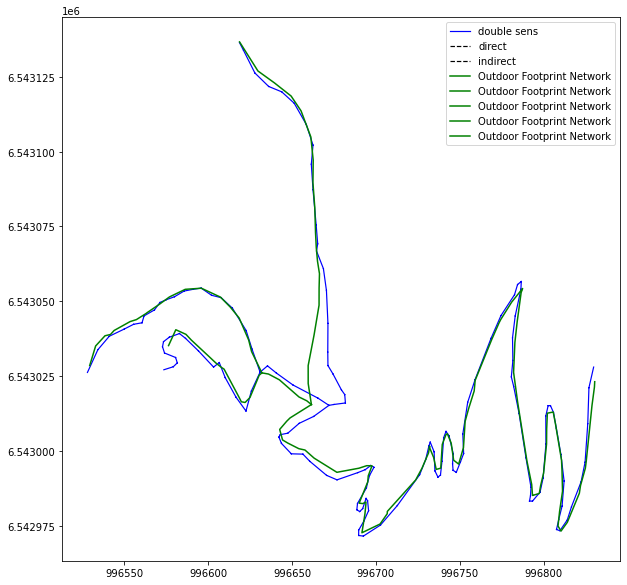

In [14]:
plt.figure(figsize=(10, 10))
ax = plt.subplot2grid((1, 1), (0, 0))

network.plot('b-', nodes='', size=1.2, append=plt)
plotConflation(RESPATH, ax, size=1.5, label='Outdoor Footprint Network')

plt.legend()